In [ ]:
import pandas as pd

# Load the datasets from each annotator
caden_df = pd.read_excel('shuffled_tiktok-health-analysis_Caden.xlsx')
yola_df = pd.read_excel('shuffled_tiktok-health-analysis_Yola.xlsx')
meryem_df = pd.read_excel('shuffled_tiktok-health-analysis_Meryem.xlsx')

# Merge the datasets on the 'ID' column
merged_df = caden_df.merge(yola_df, on='ID', suffixes=('', '_y'), how='outer')
merged_df = merged_df.merge(meryem_df, on='ID', suffixes=('', '_z'), how='outer')

# Rename the columns to follow the format 'annotator_name: label_name'
for col in caden_df.columns:
    if col != 'ID':
        merged_df.rename(columns={col: f'Caden: {col}'}, inplace=True)

for col in yola_df.columns:
    if col != 'ID':
        merged_df.rename(columns={col + '_y': f'Yola: {col}'}, inplace=True)

for col in meryem_df.columns:
    if col != 'ID':
        merged_df.rename(columns={col + '_z': f'Meryem: {col}'}, inplace=True)

# Save the merged dataset to a new Excel file
merged_df.to_excel('merged_annotations.xlsx', index=False)


In [ ]:
merged_df = pd.read_excel('merged_annotations_all_annotated_using_code.xlsx')
# Filter out rows where all annotations are False
annotation_columns = [col for col in merged_df.columns if 'Risky Behavior' in col or 'Unrisky Behavior' in col]
merged_df = merged_df[~(merged_df[annotation_columns].isna().all(axis=1) | (merged_df[annotation_columns] == False).all(axis=1))]
merged_df.to_excel('merged_annotations_all_annotated.xlsx', index=False)

In [ ]:
import pandas as pd

merged_df = pd.read_excel('merged_annotations_all_annotated_using_code.xlsx')
# Filter rows to retain only those where each annotator marked at least one category as True
annotation_columns = [col for col in merged_df.columns if 'Risky Behavior' in col or 'Unrisky Behavior' in col]

# Create a mask to check if each annotator has at least one `True` label in any of the annotation columns
caden_mask = merged_df[[col for col in annotation_columns if col.startswith('Caden:')]].any(axis=1)
yola_mask = merged_df[[col for col in annotation_columns if col.startswith('Yola:')]].any(axis=1)
meryem_mask = merged_df[[col for col in annotation_columns if col.startswith('Meryem:')]].any(axis=1)

# Filter the DataFrame to keep only rows where each annotator has marked at least one category as True
filtered_df = merged_df[caden_mask & yola_mask & meryem_mask]

# Save the filtered dataset to a new Excel file
filtered_df.to_excel('filtered_annotated_by_all.xlsx', index=False)

# Fleiss' Kappa Agreement on multiple classes

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.stats.inter_rater import fleiss_kappa

# Load your dataset

data = pd.read_excel('filtered_annotated_by_all.xlsx')

# Define the labels we are interested in
categories = [
    "Unrisky Behavior",
    "Risky Behavior (Smoking)",
    "Risky Behavior (Alcohol Consumption)",
    "Risky Behavior (Unhealthy Diet)",
    "Risky Behavior (Other)"
]

# Dictionary to store Fleiss' Kappa for each category
kappa_scores = {}

# Loop through each category to calculate Fleiss' Kappa separately
for category in categories:
    # Prepare data for Fleiss' Kappa
    category_matrix = []
    for _, row in data.iterrows():
        # Count how many annotators marked the label as True (1) or False (0)
        true_count = sum([row[f"{annotator}: {category}"] for annotator in ["Caden", "Yola", "Meryem"]])
        false_count = 3 - true_count  # Since there are 3 annotators
        category_matrix.append([true_count, false_count])

    # Convert to numpy array and calculate Fleiss' Kappa
    category_matrix = np.array(category_matrix)
    kappa_scores[category] = fleiss_kappa(category_matrix, method='fleiss')

# Display Fleiss' Kappa score for each category
for category, score in kappa_scores.items():
    print(f"Fleiss' Kappa for {category}: {score}")


Fleiss' Kappa for Unrisky Behavior: 0.6304985337243398
Fleiss' Kappa for Risky Behavior (Smoking): 0.43229036295369
Fleiss' Kappa for Risky Behavior (Alcohol Consumption): 0.65432098765432
Fleiss' Kappa for Risky Behavior (Unhealthy Diet): 0.8450565666502703
Fleiss' Kappa for Risky Behavior (Other): -0.008000000000013874


In [ ]:
import pandas as pd
import numpy as np
from statsmodels.stats.inter_rater import fleiss_kappa

# Load your dataset
data = pd.read_excel('filtered_annotated_by_all.xlsx')

# Define risky behavior categories
risky_categories = [
    "Risky Behavior (Smoking)",
    "Risky Behavior (Alcohol Consumption)",
    "Risky Behavior (Unhealthy Diet)",
    "Risky Behavior (Other)"
]

# Prepare data for Fleiss' Kappa
kappa_counts = []

# Loop through each instance (row) in the dataset
for _, row in data.iterrows():
    # Check if each annotator marked any risky behavior as True
    caden_risky = any(row[f"Caden: {category}"] for category in risky_categories)
    yola_risky = any(row[f"Yola: {category}"] for category in risky_categories)
    meryem_risky = any(row[f"Meryem: {category}"] for category in risky_categories)

    # Create a count of risky (1) and unrisky (0) annotations
    kappa_counts.append([caden_risky, yola_risky, meryem_risky])

# Create a contingency table for Fleiss' Kappa
# Count how many annotators marked each video as risky (1) or unrisky (0)
contingency_table = []

for annotations in kappa_counts:
    # Count the number of raters that marked risky behavior
    risky_count = sum(annotations)  # Count of 1s
    unrisky_count = len(annotations) - risky_count  # Count of 0s
    contingency_table.append([risky_count, unrisky_count])

# Convert to numpy array and calculate Fleiss' Kappa
contingency_table = np.array(contingency_table)
kappa_score = fleiss_kappa(contingency_table, method='fleiss')

# Display Fleiss' Kappa score
print(f"Fleiss' Kappa for Any Risky Behavior: {kappa_score:.4f}")


Fleiss' Kappa for Any Risky Behavior: 0.6305


# Percentage Agreement on multiple classes

In [ ]:
import pandas as pd

# Load your dataset

data = pd.read_excel('filtered_annotated_by_all.xlsx')

# Define the labels we are interested in
categories = [
    "Unrisky Behavior",
    "Risky Behavior (Smoking)",
    "Risky Behavior (Alcohol Consumption)",
    "Risky Behavior (Unhealthy Diet)",
    "Risky Behavior (Other)"
]

# Dictionary to store percentage agreement for each category
agreement_scores = {}

# Loop through each category to calculate percentage agreement
for category in categories:
    # Initialize agreement count
    agreement_count = 0

    # Iterate over each instance in the dataset
    for _, row in data.iterrows():
        # Collect each annotator's label for this category
        labels = [row[f"{annotator}: {category}"] for annotator in ["Caden", "Yola", "Meryem"]]

        # Check if all annotators agree (either all True or all False)
        if all(labels) or not any(labels):
            agreement_count += 1

    # Calculate percentage agreement
    total_instances = len(data)
    percentage_agreement = (agreement_count / total_instances) * 100
    agreement_scores[category] = percentage_agreement

# Display percentage agreement for each category
for category, score in agreement_scores.items():
    print(f"Percentage Agreement for {category}: {score:.2f}%")


Percentage Agreement for Unrisky Behavior: 78.57%
Percentage Agreement for Risky Behavior (Smoking): 89.29%
Percentage Agreement for Risky Behavior (Alcohol Consumption): 96.43%
Percentage Agreement for Risky Behavior (Unhealthy Diet): 94.05%
Percentage Agreement for Risky Behavior (Other): 97.62%


# Percentage Agreement on binary classification

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.stats.inter_rater import fleiss_kappa

# Load your dataset
data = pd.read_excel('filtered_annotated_by_all.xlsx')

# Define risky behavior categories
risky_categories = [
    "Risky Behavior (Smoking)",
    "Risky Behavior (Alcohol Consumption)",
    "Risky Behavior (Unhealthy Diet)",
    "Risky Behavior (Other)"
]

# Prepare data for Fleiss' Kappa
kappa_counts = []

# Loop through each instance (row) in the dataset
for _, row in data.iterrows():
    # Check if each annotator marked any risky behavior as True
    caden_risky = any(row[f"Caden: {category}"] for category in risky_categories)
    yola_risky = any(row[f"Yola: {category}"] for category in risky_categories)
    meryem_risky = any(row[f"Meryem: {category}"] for category in risky_categories)

    # Create a count of risky (1) and unrisky (0) annotations
    kappa_counts.append([caden_risky, yola_risky, meryem_risky])

# Create a contingency table for Fleiss' Kappa
# Count how many annotators marked each video as risky (1) or unrisky (0)
contingency_table = []

for annotations in kappa_counts:
    # Count the number of raters that marked risky behavior
    risky_count = sum(annotations)  # Count of 1s
    unrisky_count = len(annotations) - risky_count  # Count of 0s
    contingency_table.append([risky_count, unrisky_count])

# Convert to numpy array and calculate Fleiss' Kappa
contingency_table = np.array(contingency_table)
kappa_score = fleiss_kappa(contingency_table, method='fleiss')

# Display Fleiss' Kappa score
print(f"Fleiss' Kappa for Any Risky Behavior: {kappa_score:.4f}")


Fleiss' Kappa for Any Risky Behavior: 0.6305


# Data Analysis

In [ ]:
import pandas as pd

# Load the dataset with ground truth labels
df = pd.read_csv('GroundTruthLabels.csv')

# Filter for columns that contain the ground truth labels
ground_truth_columns = [col for col in df.columns if col.startswith('Ground Truth:')]

# Calculate the count of instances for each ground truth label
label_counts = df[ground_truth_columns].sum()

# Calculate the percentage of instances for each label
total_instances = len(df)
label_percentages = (label_counts / total_instances) * 100

# Combine counts and percentages into a DataFrame for easier display
label_stats = pd.DataFrame({
    'Count': label_counts,
    'Percentage': label_percentages
})

# Save the label stats to a new CSV file
label_stats.to_csv('LabelStats.csv', index=True)

# Display the label stats
print(label_stats)


                                                    Count  Percentage
Ground Truth: Unrisky Behavior                        114   63.687151
Ground Truth: Risky Behavior (Smoking)                 18   10.055866
Ground Truth: Risky Behavior (Alcohol Consumption)     16    8.938547
Ground Truth: Risky Behavior (Unhealthy Diet)          33   18.435754
Ground Truth: Risky Behavior (Other)                    3    1.675978


In [ ]:
import pandas as pd

# Load the dataset with ground truth labels
df = pd.read_csv('GroundTruthLabels1.csv')

# Remove duplicate rows based on the 'ID' column
df = df.drop_duplicates(subset='ID')

# Filter for columns that contain the ground truth labels
ground_truth_columns = [col for col in df.columns if col.startswith('Ground Truth:')]

# Calculate the count of instances for each ground truth label
label_counts = df[ground_truth_columns].sum()

# Calculate the percentage of instances for each label
total_instances = len(df)
label_percentages = (label_counts / total_instances) * 100

# Combine counts and percentages into a DataFrame for easier display
label_stats = pd.DataFrame({
    'Count': label_counts,
    'Percentage': label_percentages
})

# Save the label stats to a new CSV file
label_stats.to_csv('LabelStats.csv', index=True)
df.to_csv('Final_dataset.csv')
# Display the label stats
print(label_stats)


                                                    Count  Percentage
Ground Truth: Unrisky Behavior                        110   55.837563
Ground Truth: Risky Behavior (Smoking)                 22   11.167513
Ground Truth: Risky Behavior (Alcohol Consumption)     36   18.274112
Ground Truth: Risky Behavior (Unhealthy Diet)          31   15.736041
Ground Truth: Risky Behavior (Other)                    3    1.522843


Turn this into a binary classification

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the dataset
df = pd.read_csv('Final_dataset.csv')

# Check the initial structure of the DataFrame
print(df.head())

# Create a binary label for risky behavior
df['Binary_Label'] = df[['Ground Truth: Risky Behavior (Smoking)',
                          'Ground Truth: Risky Behavior (Alcohol Consumption)',
                          'Ground Truth: Risky Behavior (Unhealthy Diet)',
                          'Ground Truth: Risky Behavior (Other)']].any(axis=1)

# Convert the boolean values to 'Risky' and 'Unrisky'
df['Binary_Label'] = df['Binary_Label'].map({True: 'Risky', False: 'Unrisky'})

# Split the data into training (70%), validation (15%), and testing (15%)
X = df.drop(columns=['Binary_Label'])  # Features, adjust to drop other necessary columns
y = df['Binary_Label']  # New binary labels

# First split: 70% training, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)

# Second split: 15% validation, 15% testing from the temporary set
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

# Combine features and labels back into DataFrames
train_df = pd.concat([X_train, y_train.reset_index(drop=True)], axis=1)
val_df = pd.concat([X_val, y_val.reset_index(drop=True)], axis=1)
test_df = pd.concat([X_test, y_test.reset_index(drop=True)], axis=1)

# Add a column specifying the split
train_df['Split'] = 'train'
val_df['Split'] = 'val'
test_df['Split'] = 'test'

# Combine all splits into a single DataFrame
final_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

# Save the final DataFrame with the split information
final_df.to_csv('Final_dataset_with_split.csv', index=False)

print("Data has been split and saved to 'Final_dataset_with_split.csv'.")



   Unnamed: 0           ID             createTimeISO  commentCount  diggCount  \
0           0  6,80983E+18  2020-03-30T04:01:05.000Z          7995     683900   
1           1  6,93494E+18  2021-03-02T06:29:28.000Z            22       1926   
2           2  6,95573E+18  2021-04-27T06:46:45.000Z          1769     252500   
3           3  6,98516E+18  2021-07-15T14:28:00.000Z          8896     839100   
4           4  6,98755E+18  2021-07-22T00:51:38.000Z         21600    4800000   

   playCount  shareCount                                               text  \
0   11300000        4801  #food #intertainment #trending #foodshow #eati...   
1     232700          87  Shisha smoke #ahmedcheema775 #tiktokpakistan #...   
2    1700000        5989   Best video motivation to stop smoking cigarettes   
3    9600000        1152                                Choice #unclefluffy   
4   38300000      149500  Responder a @pauso_videosl._.l #sinlicor #mock...   

                                      

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('Final_dataset.csv')

# Check the initial structure of the DataFrame
print(df.head())

# Create the 'Risky Behavior' column
df['Risky Behavior'] = df[['Ground Truth: Risky Behavior (Smoking)',
                           'Ground Truth: Risky Behavior (Alcohol Consumption)',
                            'Ground Truth: Risky Behavior (Unhealthy Diet)',
                            'Ground Truth: Risky Behavior (Other)']].any(axis=1)

# Convert the boolean values to 'True' and 'False'
df['Risky Behavior'] = df['Risky Behavior'].map({True: True, False: False})

# Check the updated DataFrame
print(df[['Risky Behavior',
           'Ground Truth: Risky Behavior (Alcohol Consumption)',
           'Ground Truth: Risky Behavior (Unhealthy Diet)',
           'Ground Truth: Risky Behavior (Other)']].head())

# Save the updated DataFrame to a new CSV
df.to_csv('Final_dataset_with_risky_behavior_column.csv', index=False)

print("The 'Risky Behavior' column has been added and saved to 'Final_dataset_with_risky_behavior_column.csv'.")


   Unnamed: 0           ID             createTimeISO  commentCount  diggCount  \
0           0  6,80983E+18  2020-03-30T04:01:05.000Z          7995     683900   
1           1  6,93494E+18  2021-03-02T06:29:28.000Z            22       1926   
2           2  6,95573E+18  2021-04-27T06:46:45.000Z          1769     252500   
3           3  6,98516E+18  2021-07-15T14:28:00.000Z          8896     839100   
4           4  6,98755E+18  2021-07-22T00:51:38.000Z         21600    4800000   

   playCount  shareCount                                               text  \
0   11300000        4801  #food #intertainment #trending #foodshow #eati...   
1     232700          87  Shisha smoke #ahmedcheema775 #tiktokpakistan #...   
2    1700000        5989   Best video motivation to stop smoking cigarettes   
3    9600000        1152                                Choice #unclefluffy   
4   38300000      149500  Responder a @pauso_videosl._.l #sinlicor #mock...   

                                      

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the updated dataset
df = pd.read_csv('Final_dataset_with_risky_behavior_column.csv')

# Set the random seed for reproducibility
random_seed = 42

# Split the dataset into training and temp (validation + test) sets
train_df, temp_df = train_test_split(df, test_size=0.3,
                                     stratify=df['Risky Behavior'],
                                     random_state=random_seed)

# Further split the temp set into validation and test sets
val_df, test_df = train_test_split(temp_df, test_size=0.5,
                                   stratify=temp_df['Risky Behavior'],
                                   random_state=random_seed)

# Add a new column for the split
train_df['Split'] = 'Train'
val_df['Split'] = 'Validation'
test_df['Split'] = 'Test'

# Concatenate all sets back into one DataFrame
final_df = pd.concat([train_df, val_df, test_df])

# Shuffle the final DataFrame (optional)
final_df = final_df.sample(frac=1, random_state=random_seed).reset_index(drop=True)

# Check the distribution of the splits
print(final_df['Split'].value_counts())

# Save the final DataFrame to a new CSV
final_df.to_csv('Final_dataset_with_splits.csv', index=False)

print("The dataset has been split and saved to 'Final_dataset_with_splits.csv'.")


Split
Train         137
Validation     30
Test           30
Name: count, dtype: int64
The dataset has been split and saved to 'Final_dataset_with_splits.csv'.


In [ ]:
import pandas as pd
import numpy as np

# Load your dataset
df = pd.read_csv('FINAAAL.csv')

# Assuming 'Risky Behavior' is the target column with string values 'TRUE' and 'FALSE'
y_train = df[df['Split'] == 'Train']['Risky Behavior'].astype(str)  # Extracting training labels
y_val = df[df['Split'] == 'Validation']['Risky Behavior'].astype(str)      # Extracting validation labels
y_test = df[df['Split'] == 'Test']['Risky Behavior'].astype(str)    # Extracting test labels

most_common_label = y_train.mode()[0]  # Get the most common label
majority_baseline_accuracy = (y_test == most_common_label).mean()  # Calculate accuracy on the test set

print("Most common label:", most_common_label)
print("Majority Baseline Accuracy:", majority_baseline_accuracy)

# Random Baseline
# Calculate the proportions of each label in the training set
label_counts = y_train.value_counts(normalize=True)  # Get normalized counts
labels = label_counts.index  # The labels ('TRUE', 'FALSE')
probs = label_counts.values  # Their corresponding probabilities

# Generate random predictions based on the label distribution
random_predictions = np.random.choice(labels, size=len(y_test), p=probs)
random_baseline_accuracy = (random_predictions == y_test).mean()  # Calculate accuracy on the test set

print("Random Baseline Accuracy:", random_baseline_accuracy)


Most common label: False
Majority Baseline Accuracy: 0.5666666666666667
Random Baseline Accuracy: 0.4666666666666667


<ipython-input-2-f94c11cc388d>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(data=df, x="Label", y="Count", palette="viridis")


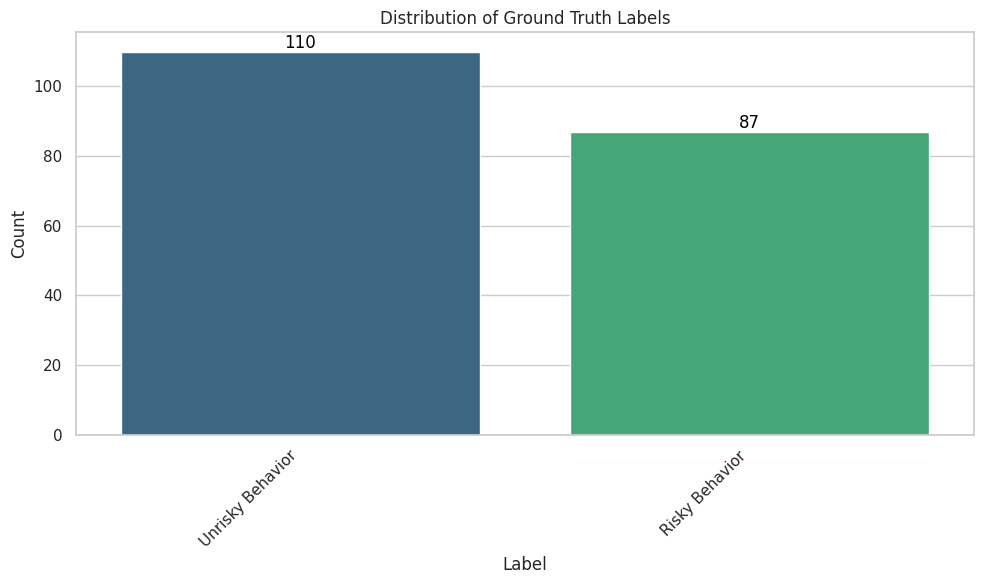

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the label data
data = {
    "Label": [
        "Unrisky Behavior",
        "Risky Behavior",
    ],
    "Count": [110, 87]
}

# Create a DataFrame
df = pd.DataFrame(data)

# Set the style
sns.set(style="whitegrid")

# Create the bar plot
plt.figure(figsize=(10, 6))
bar_plot = sns.barplot(data=df, x="Label", y="Count", palette="viridis")
bar_plot.set_title("Distribution of Ground Truth Labels")
bar_plot.set_xlabel("Label")
bar_plot.set_ylabel("Count")

# Display the counts on top of the bars
for index, row in df.iterrows():
    bar_plot.text(index, row.Count + 1, row.Count, color="black", ha="center")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score

# Load your dataset
df = pd.read_csv('FINAAAL.csv')

# Assuming 'Risky Behavior' is the target column with string values 'TRUE' and 'FALSE'
y_train = df[df['Split'] == 'Train']['Risky Behavior'].astype(str)  # Training labels
y_val = df[df['Split'] == 'Validation']['Risky Behavior'].astype(str)  # Validation labels
y_test = df[df['Split'] == 'Test']['Risky Behavior'].astype(str)  # Test labels

# Majority Baseline
most_common_label = y_train.mode()[0]  # Most common label in the training set
majority_predictions = [most_common_label] * len(y_test)  # Predict the most common label for each instance

# Calculate majority baseline F1 score
majority_baseline_f1 = f1_score(y_test, majority_predictions, pos_label="TRUE", average='binary')
print("Most Common Label:", most_common_label)
print("Majority Baseline F1 Score:", majority_baseline_f1)

# Random Baseline
# Get label distribution in the training set
label_counts = y_train.value_counts(normalize=True)
labels = label_counts.index  # Labels ('TRUE', 'FALSE')
probs = label_counts.values  # Corresponding probabilities

# Generate random predictions based on label distribution
random_predictions = np.random.choice(labels, size=len(y_test), p=probs)

# Calculate random baseline F1 score
random_baseline_f1 = f1_score(y_test, random_predictions, pos_label="TRUE", average='binary')
print("Random Baseline F1 Score:", random_baseline_f1)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score

# Load your dataset
df = pd.read_csv('FINAAAL.csv')

# Assuming 'Risky Behavior' is the target column with string values 'True' and 'False'
y_train = df[df['Split'] == 'Train']['Risky Behavior'].astype(str)  # Training labels
y_val = df[df['Split'] == 'Validation']['Risky Behavior'].astype(str)  # Validation labels
y_test = df[df['Split'] == 'Test']['Risky Behavior'].astype(str)  # Test labels

# Majority Baseline
most_common_label = y_train.mode()[0]  # Most common label in the training set
majority_predictions = [most_common_label] * len(y_test)  # Predict the most common label for each instance

# Calculate majority baseline F1 score
majority_baseline_f1 = f1_score(y_test, majority_predictions, pos_label="True", average='binary')
print("Most Common Label:", most_common_label)
print("Majority Baseline F1 Score:", majority_baseline_f1)

# Random Baseline
# Get label distribution in the training set
label_counts = y_train.value_counts(normalize=True)
labels = label_counts.index  # Labels ('True', 'False')
probs = label_counts.values  # Corresponding probabilities

# Generate random predictions based on label distribution
random_predictions = np.random.choice(labels, size=len(y_test), p=probs)

# Calculate random baseline F1 score
random_baseline_f1 = f1_score(y_test, random_predictions, pos_label="True", average='binary')
print("Random Baseline F1 Score:", random_baseline_f1)


Most Common Label: False
Majority Baseline F1 Score: 0.0
Random Baseline F1 Score: 0.3448275862068966


Initial data types:
commentCount      int64
diggCount         int64
playCount         int64
shareCount        int64
Risky Behavior     bool
dtype: object


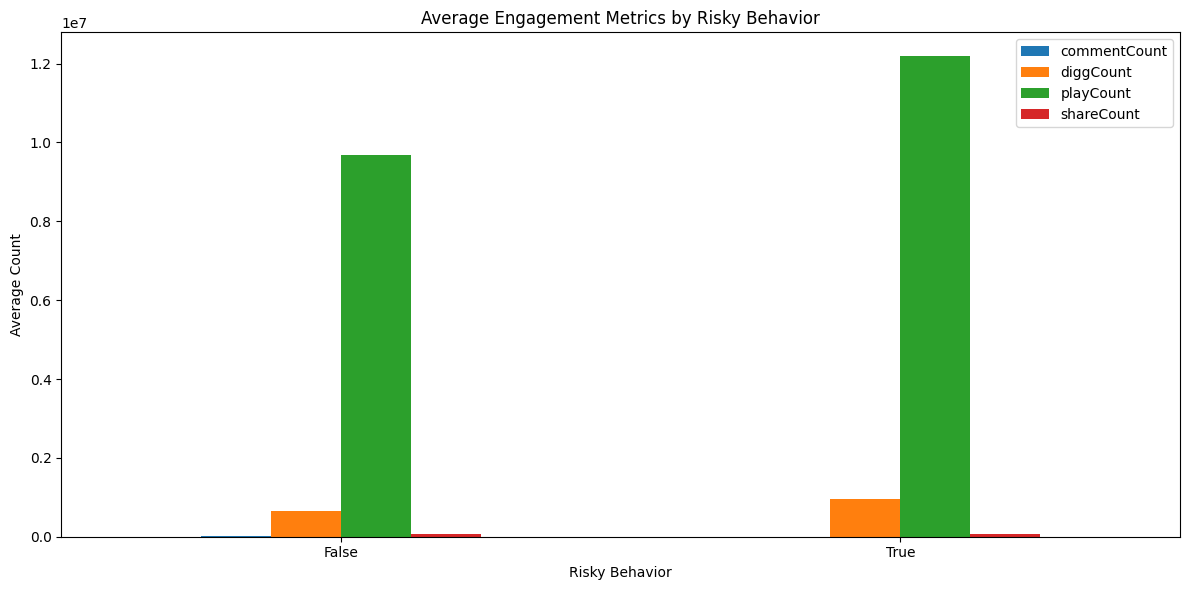

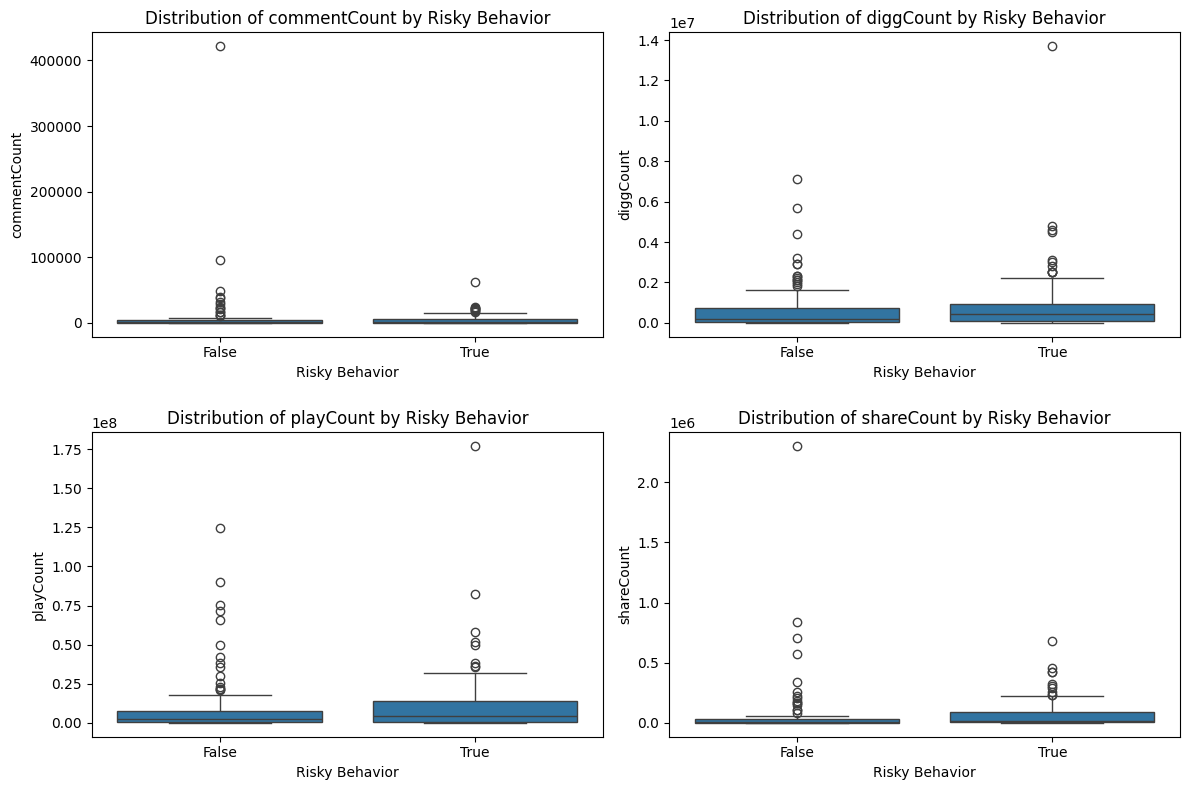

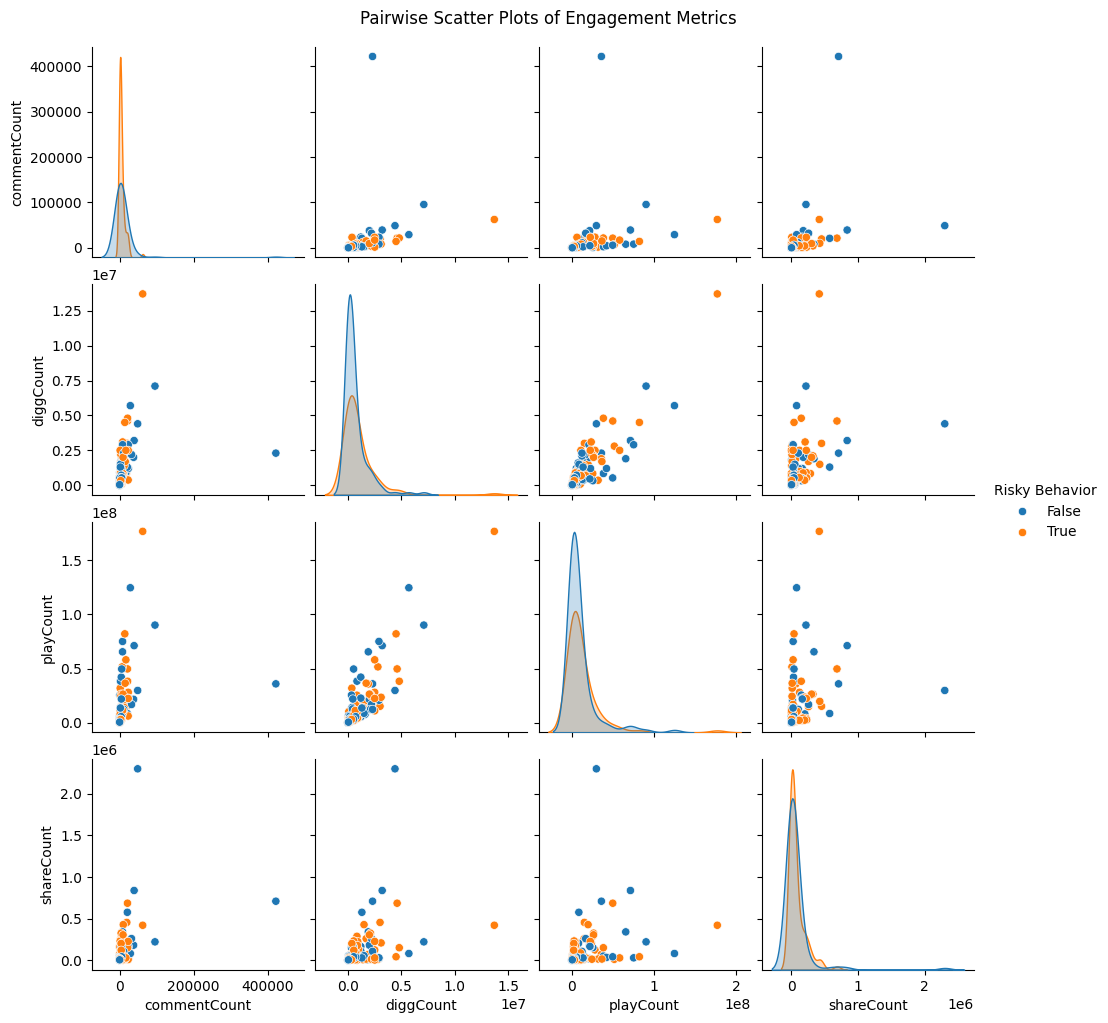

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset and only select the necessary columns
df = pd.read_csv('FINAAAL.csv', usecols=['commentCount', 'diggCount', 'playCount', 'shareCount', 'Risky Behavior'])

# Inspect data types
print('Initial data types:')
print(df.dtypes)

# Ensure "Risky Behavior" is a boolean or convert it accordingly
df['Risky Behavior'] = df['Risky Behavior'].astype(bool)

# Create bar plot for average engagement metrics by Risky Behavior
mean_engagement = df.groupby('Risky Behavior').mean()

plt.figure(figsize=(12, 6))
mean_engagement.plot(kind='bar', ax=plt.gca())
plt.title('Average Engagement Metrics by Risky Behavior')
plt.ylabel('Average Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Create box plots for distribution of engagement metrics
plt.figure(figsize=(12, 8))
for i, column in enumerate(['commentCount', 'diggCount', 'playCount', 'shareCount'], 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='Risky Behavior', y=column, data=df)
    plt.title(f'Distribution of {column} by Risky Behavior')
plt.tight_layout()
plt.show()

# Create pairplot for scatter plots
sns.pairplot(df, hue='Risky Behavior', vars=['commentCount', 'diggCount', 'playCount', 'shareCount'])
plt.suptitle('Pairwise Scatter Plots of Engagement Metrics', y=1.02)
plt.show()


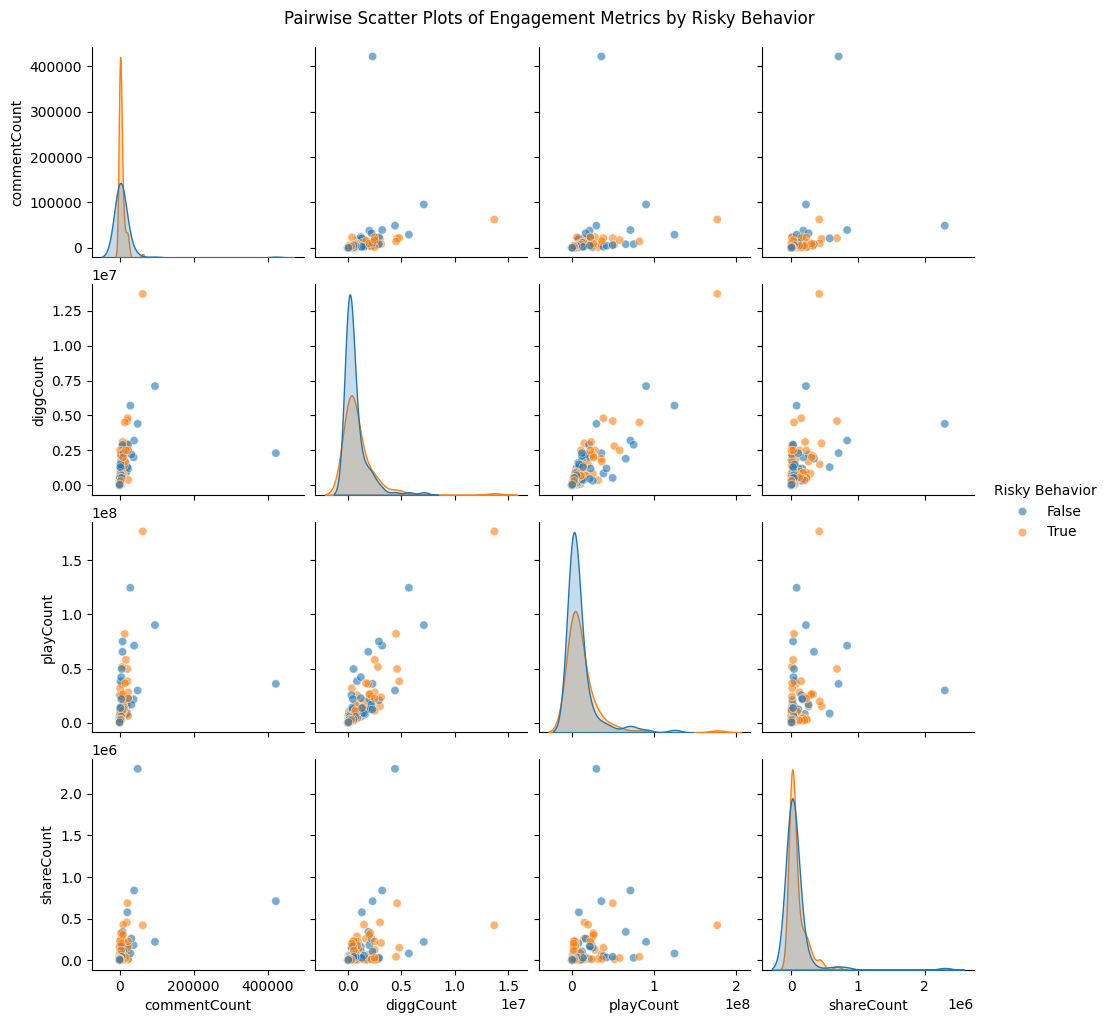

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('FINAAAL.csv', usecols=['commentCount', 'diggCount', 'playCount', 'shareCount', 'Risky Behavior'])

# Ensure the 'Risky Behavior' column is in the correct boolean format
df['Risky Behavior'] = df['Risky Behavior'].astype(bool)

# Create a pairplot
sns.pairplot(df, vars=['commentCount', 'diggCount', 'playCount', 'shareCount'], hue='Risky Behavior', plot_kws={'alpha':0.6}, diag_kind='kde')

# Enhance the plot's layout and titles
plt.suptitle('Pairwise Scatter Plots of Engagement Metrics by Risky Behavior', y=1.02)
plt.savefig('pairwise_scatter_plot.png', dpi=300)  # Save the plot if necessary
plt.show()

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel
from torchvision import transforms, models
import cv2
import pandas as pd
import os

# Load dataset
file_path = 'TrainAModel.csv'
data = pd.read_csv(file_path)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Paths to video folders
video_folders = {
    "train": "/content/drive/MyDrive/TiktokVideos/Videos/Train",
    "validation": "/content/drive/MyDrive/TiktokVideos/Videos/Validation",
    "test": "/content/drive/MyDrive/TiktokVideos/Test"
}

# Define data transformation for image frames
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Custom Dataset class
from PIL import Image

class VideoDataset(Dataset):
    def __init__(self, data, split, tokenizer, transform):
        self.data = data[data["Split"] == split]
        self.tokenizer = tokenizer
        self.transform = transform
        self.split = split

    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        # Textual features
        text = row["text"]
        if not isinstance(text, str):  # Ensure text is a string
            text = ""
        encoding = self.tokenizer(
            text, padding='max_length', truncation=True, max_length=128, return_tensors='pt'
        )

        # Visual features: Extract frames from video
        video_path = os.path.join(video_folders[self.split], row["Video Name"])
        frames = self.load_frames(video_path)

        label = torch.tensor(int(row["Risky Behavior"]))
        return encoding, frames, label


    def load_frames(self, video_path):
        cap = cv2.VideoCapture(video_path)
        frames = []
        frame_count = 0
        while frame_count < 10:  # Limit to 10 frames for efficiency
            success, frame = cap.read()
            if not success:
                break
            # Convert frame (NumPy array) to PIL image
            frame = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            frame = self.transform(frame)
            frames.append(frame)
            frame_count += 1
        cap.release()
        return torch.stack(frames)


# Load tokenizer for text processing
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
train_dataset = VideoDataset(data, "train", tokenizer, transform)
val_dataset = VideoDataset(data, "validation", tokenizer, transform)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4)


In [ ]:
import torch
import torch.nn as nn
from transformers import AutoModel, AutoTokenizer
import torchvision.models as models
import torch
import torch.nn as nn
from transformers import AutoModel, AutoTokenizer
import torchvision.models as models

import os
import json

class MultimodalRiskBehaviorModel(nn.Module):
    def __init__(self, text_model_name="bert-base-uncased", visual_model_name="resnet50", hidden_dim=512, dropout=0.3):
        super(MultimodalRiskBehaviorModel, self).__init__()

        # Load the text model (e.g., BERT)
        self.text_model = AutoModel.from_pretrained(text_model_name)
        self.tokenizer = AutoTokenizer.from_pretrained(text_model_name)

        # Load the visual model (e.g., ResNet50)
        self.visual_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        visual_feature_dim = self.visual_model.fc.in_features
        self.visual_model.fc = nn.Identity()  # Remove final classification layer

        # Combine text and visual features and create classifier layers
        text_feature_dim = self.text_model.config.hidden_size
        self.fc1 = nn.Linear(text_feature_dim + visual_feature_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, encoding, frames):
        input_ids = encoding['input_ids'].squeeze(1).to(device)
        attention_mask = encoding['attention_mask'].squeeze(1).to(device)
        text_features = self.text_model(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:, 0, :]

        batch_size, num_frames, channels, height, width = frames.size()
        frames = frames.view(batch_size * num_frames, channels, height, width)
        visual_features = self.visual_model(frames)
        visual_features = visual_features.view(batch_size, num_frames, -1).mean(dim=1)

        combined_features = torch.cat((text_features, visual_features), dim=1)
        x = self.dropout(torch.relu(self.fc1(combined_features)))
        output = torch.sigmoid(self.fc2(x))
        return output

    def save_pretrained(self, save_directory):
        """Save model weights and config."""
        os.makedirs(save_directory, exist_ok=True)

        # Save the model weights
        torch.save(self.state_dict(), os.path.join(save_directory, 'pytorch_model.bin'))

        # Save the model config
        config = {
            'text_model_name': 'bert-base-uncased',
            'visual_model_name': 'resnet50',
            'hidden_dim': 512,
            'dropout': 0.3
        }
        with open(os.path.join(save_directory, 'config.json'), 'w') as f:
            json.dump(config, f)

        # Save the tokenizer
        self.tokenizer.save_pretrained(save_directory)

    @classmethod
    def from_pretrained(cls, load_directory):
        """Load the model from the specified directory."""
        with open(os.path.join(load_directory, 'config.json')) as f:
            config = json.load(f)

        model = cls(
            text_model_name=config['text_model_name'],
            visual_model_name=config['visual_model_name'],
            hidden_dim=config['hidden_dim'],
            dropout=config['dropout']
        )

        # Load the weights
        model.load_state_dict(torch.load(os.path.join(load_directory, 'pytorch_model.bin'), map_location='cpu'))

        return model



In [ ]:
# Initialize model
model = MultimodalRiskBehaviorModel().to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=5):
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for encoding, frames, labels in train_loader:
            labels = labels.float().to(device)
            optimizer.zero_grad()

            outputs = model(encoding, frames)
            loss = criterion(outputs.squeeze(-1), labels)  # Use squeeze(-1) to match the label shape
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        val_loss = validate_model(model, val_loader, criterion)
        print(f"Epoch [{epoch + 1}/{epochs}], Train Loss: {running_loss / len(train_loader):.4f}, Val Loss: {val_loss:.4f}")

def validate_model(model, val_loader, criterion):
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for encoding, frames, labels in val_loader:
            labels = labels.float().to(device)
            outputs = model(encoding, frames)
            loss = criterion(outputs.squeeze(-1), labels)  # Use squeeze(-1) here as well
            val_loss += loss.item()
    model.train()
    return val_loss / len(val_loader)

train_model(model, train_loader, val_loader, criterion, optimizer, epochs=5)

In [ ]:
model = MultimodalRiskBehaviorModel().to(device)

# Save the model
save_path = './multimodal_risk_behavior_model'
model.save_pretrained(save_path)


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:01<00:00, 71.9MB/s]


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(model, test_loader):
    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for encoding, frames, labels in test_loader:
            labels = labels.float().to(device)
            outputs = model(encoding, frames)
            preds = (outputs.squeeze(-1) > 0.5).float()  # Apply threshold for binary classification

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    # Calculate evaluation metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    roc_auc = roc_auc_score(all_labels, all_preds)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")

    model.train()  # Return model to training mode if further training is needed
    return accuracy, precision, recall, f1, roc_auc

# Define the test dataset and data loader
test_dataset = VideoDataset(data, "test", tokenizer, transform)
test_loader = DataLoader(test_dataset, batch_size=4)


In [ ]:
accuracy, precision, recall, f1, roc_auc = evaluate_model(model, test_loader)

#HF

In [ ]:
import torch
from torch.utils.data import Dataset
from transformers import AutoModel, AutoTokenizer
from torchvision import transforms, models
import torch.nn as nn
import os
import json
import cv2
from PIL import Image


class VideoDataset(Dataset):
    def __init__(self, data, split, tokenizer, transform, video_folders):
        self.data = data[data["Split"] == split]
        self.tokenizer = tokenizer
        self.transform = transform
        self.video_folders = video_folders
        self.split = split

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        text = row["text"] if isinstance(row["text"], str) else ""
        encoding = self.tokenizer(text, padding='max_length', truncation=True, max_length=128, return_tensors='pt')
        video_path = os.path.join(self.video_folders[self.split], row["Video Name"])
        frames = self.load_frames(video_path)
        label = torch.tensor(int(row["Risky Behavior"]))
        return encoding, frames, label

    def load_frames(self, video_path):
        cap = cv2.VideoCapture(video_path)
        frames = []
        frame_count = 0
        if not cap.isOpened():
            print(f"Error: Couldn't open video file at {video_path}")
            return torch.zeros(1, 3, 224, 224)  # Return a default tensor if video can't be opened

        while frame_count < 10:  # Limit to 10 frames for efficiency
            success, frame = cap.read()
            if not success:
                print(f"Warning: Couldn't read frame {frame_count + 1} from {video_path}")
                break  # Stop if frames can't be read

            # Convert frame (NumPy array) to PIL image
            frame = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            frame = self.transform(frame)
            frames.append(frame)
            frame_count += 1

        cap.release()

        # Check if no frames were loaded
        if len(frames) == 0:
            print(f"Warning: No frames extracted from {video_path}. Returning a tensor of zeros.")
            return torch.zeros(10, 3, 224, 224)  # Return a tensor of zeros if no frames were found

        return torch.stack(frames)



class MultimodalRiskBehaviorModel(nn.Module):
    def __init__(self, text_model_name="bert-base-uncased", hidden_dim=512, dropout=0.3):
        super(MultimodalRiskBehaviorModel, self).__init__()

        # Text model
        self.text_model_name = text_model_name
        self.text_model = AutoModel.from_pretrained(text_model_name)

        # Visual model (ResNet50)
        self.visual_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

        # Save the original `fc.in_features` before replacing it
        visual_feature_dim = self.visual_model.fc.in_features
        self.visual_model.fc = nn.Identity()  # Replace with identity layer

        # Get the hidden dimension of the text model
        text_feature_dim = self.text_model.config.hidden_size

        # Fusion and classification layers
        self.fc1 = nn.Linear(text_feature_dim + visual_feature_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, encoding, frames):
        input_ids = encoding['input_ids'].squeeze(1).to(device)
        attention_mask = encoding['attention_mask'].squeeze(1).to(device)

        # Text embeddings from BERT
        text_features = self.text_model(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:, 0, :]

        # Visual features from ResNet50
        frames = frames.to(device)  # Move frames to the same device as the model

        batch_size, num_frames, channels, height, width = frames.size()
        frames = frames.view(batch_size * num_frames, channels, height, width)
        visual_features = self.visual_model(frames)

        # Reshape back to (batch_size, num_frames, visual_feature_dim)
        visual_features = visual_features.view(batch_size, num_frames, -1).mean(dim=1)

        # Combine text and visual features
        combined_features = torch.cat((text_features, visual_features), dim=1)

        # Pass through the classifier
        x = self.dropout(torch.relu(self.fc1(combined_features)))
        output = torch.sigmoid(self.fc2(x))  # Sigmoid for binary classification

        return output
    def save_pretrained(self, save_directory):
        os.makedirs(save_directory, exist_ok=True)
        torch.save(self.state_dict(), os.path.join(save_directory, 'pytorch_model.bin'))
        config = {
            "text_model_name": self.text_model_name,
            "hidden_dim": self.fc1.out_features
        }
        with open(os.path.join(save_directory, 'config.json'), 'w') as f:
            json.dump(config, f)
    @classmethod
    def from_pretrained(cls, load_directory, map_location=None):
        with open(os.path.join(load_directory, 'config.json'), 'r') as f:
            config = json.load(f)

        model = cls(text_model_name=config["text_model_name"], hidden_dim=config["hidden_dim"])

        state_dict = torch.load(
            os.path.join(load_directory, 'pytorch_model.bin'),
            map_location=map_location
        )
        model.load_state_dict(state_dict)

        return model


In [ ]:
import torch
from torch.utils.data import DataLoader
import pandas as pd
#from model import MultimodalRiskBehaviorModel, VideoDataset
#from utils import train_model, evaluate_model
import torchvision.transforms as transforms
from transformers import AutoTokenizer

import torch.nn as nn

# Dataset & Dataloader
data = pd.read_csv('TrainAModel.csv')
video_folders = {
    "train": "/content/drive/MyDrive/TiktokVideos/Videos/Train",
    "validation": "/content/drive/MyDrive/TiktokVideos/Videos/Validation",
    "test": "/content/drive/MyDrive/TiktokVideos/Test"
}


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

train_dataset = VideoDataset(data, "train", tokenizer, transform, video_folders)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

model = MultimodalRiskBehaviorModel().to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)

for epoch in range(5):
    model.train()
    running_loss = 0.0
    for encoding, frames, labels in train_loader:
        labels = labels.float().to(device)
        optimizer.zero_grad()
        outputs = model(encoding, frames)
        # Ensure the shape of output is [batch_size, 1] for binary cross-entropy
        loss = criterion(outputs.squeeze(-1), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch [{epoch+1}/5], Loss: {running_loss / len(train_loader):.4f}")

# Save the model to HuggingFace format
model.save_pretrained('./multimodal_risk_behavior_model')
tokenizer.save_pretrained('./multimodal_risk_behavior_model')




Epoch [1/5], Loss: 0.6848
Epoch [2/5], Loss: 0.6628
Epoch [3/5], Loss: 0.5910
Epoch [4/5], Loss: 0.4338
Epoch [5/5], Loss: 0.2451


('./multimodal_risk_behavior_model/tokenizer_config.json',
 './multimodal_risk_behavior_model/special_tokens_map.json',
 './multimodal_risk_behavior_model/vocab.txt',
 './multimodal_risk_behavior_model/added_tokens.json',
 './multimodal_risk_behavior_model/tokenizer.json')

In [ ]:
video_folders = {
    "train": "/content/drive/MyDrive/TiktokVideos/Videos/Train",
    "validation": "/content/drive/MyDrive/TiktokVideos/Videos/Validation",
    "test": "/content/drive/MyDrive/TiktokVideos/Videos/Test"
}
# Example: Creating the dataset for the "test" split
test_dataset = VideoDataset(data, "test", tokenizer, transform, video_folders)

# Accessing the first item in the test dataset
index = 0
encoding, frames, label = test_dataset[index]

# Displaying the retrieved components
print("Text Encoding (input_ids):", encoding['input_ids'])
print("Text Encoding (attention_mask):", encoding['attention_mask'])
print("Video Frames Shape:", frames.shape)
print("Label:", label)


Text Encoding (input_ids): tensor([[  101,  2043,  3566,  3084,  2014,  2833,  2298,  2488,  1010,  2029,
          2028,  2052,  2017,  4521,  1029,  1001,  1042, 22571,  1001,  2005,
         29337, 13704,  1001,  2833,  1001, 18064,  1001, 14163,  2243, 25153,
          1001,  8808,  1001,  6097,  5685, 25923,  3366,  1001, 17387,  1001,
          9850,  1001,  9485,  1001,  7967,  1001,  8434,  1001,  2128, 20051,
          3085,   102,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,   

In [ ]:
# Define the test dataset and data loader
test_dataset = VideoDataset(data, "test", tokenizer, transform, video_folders)
test_loader = DataLoader(test_dataset, batch_size=4)

# Function to evaluate the model
def evaluate_model(model, test_loader):
    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for encoding, frames, labels in test_loader:
            labels = labels.float().to(device)
            outputs = model(encoding, frames)
            preds = (outputs.squeeze(-1) > 0.5).float()  # Apply threshold for binary classification

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    # Calculate evaluation metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    roc_auc = roc_auc_score(all_labels, all_preds)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")

    model.train()  # Return model to training mode if further training is needed
    return accuracy, precision, recall, f1, roc_auc

# Evaluate the model on the test set
accuracy, precision, recall, f1, roc_auc = evaluate_model(model, test_loader)


Accuracy: 0.6333
Precision: 0.5500
Recall: 0.8462
F1 Score: 0.6667
ROC AUC: 0.6584


In [ ]:
import torch
from PIL import Image
import cv2

# Prediction function for a single video
def predict_video(model, video_path, text_input, tokenizer, transform):
    # Set model to evaluation mode
    model.eval()

    # Tokenize the text input
    encoding = tokenizer(
        text_input, padding='max_length', truncation=True, max_length=128, return_tensors='pt'
    )

    # Load frames from the video
    frames = load_frames_from_video(video_path, transform)

    # Move to device (GPU/CPU)
    encoding = {key: val.to(device) for key, val in encoding.items()}
    frames = frames.to(device)

    # Perform forward pass through the model
    with torch.no_grad():
        output = model(encoding, frames)

    # Apply sigmoid to get probability, then threshold to get prediction
    prediction = (output.squeeze(-1) > 0.5).float()

    # Return the predicted label (0 or 1)
    return prediction.item()

# Function to load frames from a video
def load_frames_from_video(video_path, transform, num_frames=10):
    cap = cv2.VideoCapture(video_path)
    frames = []
    frame_count = 0
    while frame_count < num_frames:  # Limit to a number of frames for efficiency
        success, frame = cap.read()
        if not success:
            break
        # Convert frame (NumPy array) to PIL image and apply transformations
        frame = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        frame = transform(frame)
        frames.append(frame)
        frame_count += 1
    cap.release()

    # Stack frames and add batch dimension (1, num_frames, channels, height, width)
    frames = torch.stack(frames)
    frames = frames.unsqueeze(0)  # Add batch dimension
    return frames


# Example usage
video_path = '/content/drive/MyDrive/TiktokVideos/Videos/Test/17-Yo cayendo en el alcoholismo #ternurines #calico7395229536092228869.mp4'  # Path to the video you want to predict on
text_input = "Yo cayendo en el alcoholismo #ternurines #calicocritters #calicocritterstiktok #sylvanianfamilies #sylvanianfamiliescollection #ternurinesmexico #ternurinesmylove #ternurinesbelicos"  # Text description associated with the video

# Get prediction
prediction = predict_video(model, video_path, text_input, tokenizer, transform)
print(f"Predicted label: {prediction}")


Predicted label: 0.0


In [ ]:
# Example usage
video_path = '/content/drive/MyDrive/TiktokVideos/Videos/Test/22-all workout guides l!nked in bi0 ⧸⧸ honestly hug7368980296215137578.mp4'  # Path to the video you want to predict on
text_input = "all workout guides l!nked in bi0 // honestly huge moment 😂 I’ve been so focused on growing my upper body that this feels like it finally shows! shorts from @KEEPTHATPUMP #upperbody #upperbodyworkout #glutegains #glutegrowth #gluteexercise #workout #strengthtraining #gym #trending #fyp"
# Get prediction
prediction = predict_video(model, video_path, text_input, tokenizer, transform)
print(f"Predicted label: {prediction}")

Predicted label: 0.0


# HF Space

In [ ]:
!pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.2/320.2 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.8/94.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.2/73.2 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.8/63.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.2/168.2 kB 10.9 MB/s eta 0:00:00
  Attempting uninstall: markupsafe
    Found existing installation: MarkupSafe 3.0.2
    Uninstalling MarkupSafe-3.0.2:
      Successfully uninstalled MarkupSafe-3.0.2


In [ ]:
tokenizer = AutoTokenizer.from_pretrained('/content/multimodal_risk_behavior_model')

In [ ]:
model = MultimodalRiskBehaviorModel.from_pretrained('/content/multimodal_risk_behavior_model',map_location='cpu')

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:01<00:00, 54.8MB/s]
<ipython-input-1-54026b751494>:127: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the load

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

MultimodalRiskBehaviorModel(
  (text_model): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), ep

In [ ]:
# Prediction function for a single video
def predict_video(model, video_path, text_input, tokenizer, transform):
    # Set model to evaluation mode
    model.eval()

    # Tokenize the text input and move to device
    encoding = tokenizer(
        text_input, padding='max_length', truncation=True, max_length=128, return_tensors='pt'
    )
    encoding = {key: val.to(device) for key, val in encoding.items()}  # Ensure text input is on the device

    # Load frames from the video and move to device
    frames = load_frames_from_video(video_path, transform)
    frames = frames.to(device)  # Ensure frames are on the device

    # Perform forward pass through the model
    with torch.no_grad():
        output = model(encoding, frames)

    # Apply sigmoid to get probability, then threshold to get prediction
    prediction = (output.squeeze(-1) > 0.5).float()

    # Return the predicted label (0 or 1)
    return prediction.item()

# Function to load frames from a video
def load_frames_from_video(video_path, transform, num_frames=10):
    cap = cv2.VideoCapture(video_path)
    frames = []
    frame_count = 0
    while frame_count < num_frames:  # Limit to a number of frames for efficiency
        success, frame = cap.read()
        if not success:
            break
        # Convert frame (NumPy array) to PIL image and apply transformations
        frame = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        frame = transform(frame)
        frames.append(frame)
        frame_count += 1
    cap.release()

    # Stack frames and add batch dimension (1, num_frames, channels, height, width)
    frames = torch.stack(frames)
    frames = frames.unsqueeze(0)  # Add batch dimension
    return frames


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Example usage
video_path = '/content/drive/MyDrive/TiktokVideos/Videos/Train/28-Everytime i start a diet  كل مرة أحاول أبدأ ريجي7219853772204281094.mp4'  # Path to the video you want to predict on
text_input = "Everytime i start a diet  كل مرة أحاول أبدأ ريجيم 😓 #dietmemes #funnyvideos #animetiktok"
prediction = predict_video(model, video_path, text_input, tokenizer, transform)
print(f"Predicted label: {prediction}")

Predicted label: 1.0


In [ ]:
import gradio as gr
import torch

# Define your video paths and captions
video_paths = [
    'https://drive.google.com/uc?export=download&id=1iWq1q1LM-jmf4iZxOqZTw4FaIBekJowM',
    'https://drive.google.com/uc?export=download&id=1_egBaC1HD2kIZgRRKsnCtsWG94vg1c7n',
    'https://drive.google.com/uc?export=download&id=12cGxBEkfU5Q1Ezg2jRk6zGyn2hoR3JLj'
]

video_captions = [
    "Everytime i start a diet  كل مرة أحاول أبدأ ريجيم 😓 #dietmemes #funnyvideos #animetiktok",
    "New sandwich from burger king 🍔👑 #mukbang #asmr #asmrmukbang #asmrsounds #eat #food #Foodie moe eats #yummy #cheese #chicken #burger #fries #burgerking @Burger King",
    "all workout guides l!nked in bi0 // honestly huge moment 😂 I’ve been so focused on growing my upper body that this feels like it finally shows! shorts from @KEEPTHATPUMP #upperbody #upperbodyworkout #glutegains #glutegrowth #gluteexercise #workout #strengthtraining #gym #trending #fyp"
]

def predict_risk(video_index):
    video_path = video_paths[video_index]
    text_input = video_captions[video_index]

    # Make prediction
    prediction = predict_video(model, video_path, text_input, tokenizer, transform)

    # Return the corresponding label
    return "Risky Health Behavior" if prediction == 1 else "Not Risky Health Behavior"

# Interface setup
with gr.Blocks() as interface:
    gr.Markdown("# Risk Behavior Prediction")
    gr.Markdown("Select a video to classify its behavior as risky or not.")

    # Input option selector
    video_selector = gr.Radio(["Video 1", "Video 2", "Video 3"], label="Choose a Video")

    # Use function to return URLs which are handled by the Gradio `gr.Video` component
    def show_selected_video(choice):
        idx = int(choice.split()[-1]) - 1
        return video_paths[idx], f"**Caption:** {video_captions[idx]}"

    video_player = gr.Video(width=320, height=240)
    caption_box = gr.Markdown()

    video_selector.change(
        fn=show_selected_video,
        inputs=video_selector,
        outputs=[video_player, caption_box]
    )

    # Prediction button and output
    predict_button = gr.Button("Predict Risk")
    output_text = gr.Textbox(label="Prediction")

    predict_button.click(
        fn=lambda idx: predict_risk(int(idx.split()[-1]) - 1),
        inputs=video_selector,
        outputs=output_text
    )

# Launch the app
interface.launch()

Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a6003d088064f0d1c7.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import gradio as gr
from transformers import AutoTokenizer
import torch
from PIL import Image
import cv2
import numpy as np


# Load the model and tokenizer from the folder where the model is saved
tokenizer = AutoTokenizer.from_pretrained('/content/multimodal_risk_behavior_model')
model = MultimodalRiskBehaviorModel.from_pretrained('/content/multimodal_risk_behavior_model')

# Set the device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

import tempfile
import shutil

# Function to load frames from a video
def load_frames_from_video(video_file, num_frames=10):
    # Save the uploaded video to a temporary file
    with tempfile.NamedTemporaryFile(delete=False) as tmp_file:
        # Write the video data to the temp file
        tmp_file.write(video_file.read())
        tmp_file_path = tmp_file.name

    # Now load the video using OpenCV from the temporary file
    cap = cv2.VideoCapture(tmp_file_path)
    frames = []
    frame_count = 0
    while frame_count < num_frames:  # Limit to a number of frames for efficiency
        success, frame = cap.read()
        if not success:
            break
        # Convert frame (NumPy array) to PIL image and apply transformations
        frame = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        frames.append(frame)
        frame_count += 1
    cap.release()

    # Remove the temporary file after reading
    os.remove(tmp_file_path)

    # Stack frames and add batch dimension (1, num_frames, channels, height, width)
    frames = np.stack(frames)
    frames = torch.tensor(frames).unsqueeze(0)  # Add batch dimension
    return frames


def predict_video(video_file, text_input):
    try:
        # Tokenize the text input
        encoding = tokenizer(text_input, padding='max_length', truncation=True, max_length=128, return_tensors='pt')

        # Load frames from the uploaded video
        frames = load_frames_from_video(video_file.name)

        # Print shapes and devices for debugging
        print(f"Text input device: {encoding['input_ids'].device}, shape: {encoding['input_ids'].shape}")
        print(f"Video frames device: {frames.device}, shape: {frames.shape}")

        # Move both the text and frames to the same device
        encoding = {key: val.to(device) for key, val in encoding.items()}
        frames = frames.to(device)

        # Perform forward pass through the model
        with torch.no_grad():
            output = model(encoding, frames)
            print(f"Output device: {output.device}, shape: {output.shape}")

        # Apply sigmoid to get probability, then threshold to get prediction
        prediction = (output.squeeze(-1) > 0.5).float()
        return "Risky Behavior" if prediction.item() == 1 else "No Risky Behavior"

    except Exception as e:
        print(f"Error during prediction: {e}")
        return f"Error: {str(e)}"



# Gradio interface setup
inputs = [
    gr.Video(label="Upload Video"),   # Video input
    gr.Textbox(label="Text Description", placeholder="Enter text associated with the video", lines=2)  # Text input
]
outputs = gr.Textbox(label="Prediction")

# Launch the Gradio interface
gr.Interface(fn=predict_video, inputs=inputs, outputs=outputs, live=True).launch()


<ipython-input-40-f804a9837217>:127: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(os.path.join(load_directory, 'pytorch_model.bin')))


Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3b42e4464f831016af.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:

# Gradio interface setup with updated syntax
inputs = [
    gr.Video(label="Upload Video"),   # Video input
    gr.Textbox(label="Text Description", placeholder="Enter text associated with the video", lines=2)  # Text input
]
outputs = gr.Textbox(label="Prediction")

# Launch the Gradio interface
gr.Interface(fn=predict_video, inputs=inputs, outputs=outputs, live=True).launch()

Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7c5aee5e90a75e291e.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import gradio as gr
from transformers import AutoModel, AutoTokenizer
import torch
from PIL import Image
import cv2
import numpy as np

# Load the model and tokenizer from the Hugging Face Hub
model = AutoModel.from_pretrained("Souha-BH/BERT_Resnet50")
tokenizer = AutoTokenizer.from_pretrained("Souha-BH/BERT_Resnet50")

# Define device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Function to load frames from a video
def load_frames_from_video(video_path, num_frames=10):
    cap = cv2.VideoCapture(video_path)
    frames = []
    frame_count = 0
    while frame_count < num_frames:  # Limit to a number of frames for efficiency
        success, frame = cap.read()
        if not success:
            break
        # Convert frame (NumPy array) to PIL image and apply transformations
        frame = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        frames.append(frame)
        frame_count += 1
    cap.release()

    # Stack frames and add batch dimension (1, num_frames, channels, height, width)
    frames = np.stack(frames)
    frames = torch.tensor(frames).unsqueeze(0)  # Add batch dimension
    return frames

# Prediction function
def predict_video(video_file, text_input):
    # Tokenize the text input
    encoding = tokenizer(text_input, padding='max_length', truncation=True, max_length=128, return_tensors='pt')

    # Load frames from the uploaded video
    frames = load_frames_from_video(video_file.name)

    # Move to device (GPU/CPU)
    encoding = {key: val.to(device) for key, val in encoding.items()}
    frames = frames.to(device)

    # Perform forward pass through the model
    with torch.no_grad():
        output = model(encoding, frames)

    # Apply sigmoid to get probability, then threshold to get prediction
    prediction = (output.squeeze(-1) > 0.5).float()

    return "Risky Behavior" if prediction.item() == 1 else "No Risky Behavior"

# Gradio interface setup
inputs = [
    gr.inputs.Video(label="Upload Video",
                   default="path/to/video1.mp4"),  # Example video 1
    gr.inputs.Textbox(label="Text Description", placeholder="Enter text associated with the video", lines=2)
]

outputs = gr.outputs.Textbox(label="Prediction")

# Example videos to use as input
example_videos = [
    "path/to/video1.mp4",  # Replace with paths to your example videos
    "path/to/video2.mp4",  # Replace with paths to your example videos
    "path/to/video3.mp4"   # Replace with paths to your example videos
]

gr.Interface(fn=predict_video, inputs=inputs, outputs=outputs, examples=example_videos, live=True).launch()
